<a href="https://colab.research.google.com/github/deborahpongeluppe/Deborahpongeluppe/blob/main/Modalfitness.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Analysis of the Modal Fitness Gym Chain


In [2]:
import pandas as pd

In [4]:
from google.colab import files
uploaded = files.upload()

Saving gym_churn_us.csv to gym_churn_us.csv


In [5]:
gym_churn_us=pd.read_csv('gym_churn_us.csv')
print(gym_churn_us.head())

   gender  Near_Location  Partner  Promo_friends  Phone  Contract_period  \
0       1              1        1              1      0                6   
1       0              1        0              0      1               12   
2       0              1        1              0      1                1   
3       0              1        1              1      1               12   
4       1              1        1              1      1                1   

   Group_visits  Age  Avg_additional_charges_total  Month_to_end_contract  \
0             1   29                     14.227470                    5.0   
1             1   31                    113.202938                   12.0   
2             0   28                    129.448479                    1.0   
3             1   33                     62.669863                   12.0   
4             0   26                    198.362265                    1.0   

   Lifetime  Avg_class_frequency_total  Avg_class_frequency_current_month  \
0  

In [6]:
print(gym_churn_us.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

In [7]:
print(gym_churn_us.describe())

            gender  Near_Location      Partner  Promo_friends        Phone  \
count  4000.000000    4000.000000  4000.000000    4000.000000  4000.000000   
mean      0.510250       0.845250     0.486750       0.308500     0.903500   
std       0.499957       0.361711     0.499887       0.461932     0.295313   
min       0.000000       0.000000     0.000000       0.000000     0.000000   
25%       0.000000       1.000000     0.000000       0.000000     1.000000   
50%       1.000000       1.000000     0.000000       0.000000     1.000000   
75%       1.000000       1.000000     1.000000       1.000000     1.000000   
max       1.000000       1.000000     1.000000       1.000000     1.000000   

       Contract_period  Group_visits          Age  \
count      4000.000000   4000.000000  4000.000000   
mean          4.681250      0.412250    29.184250   
std           4.549706      0.492301     3.258367   
min           1.000000      0.000000    18.000000   
25%           1.000000      0.00

In [8]:
print(gym_churn_us.isnull().sum())

gender                               0
Near_Location                        0
Partner                              0
Promo_friends                        0
Phone                                0
Contract_period                      0
Group_visits                         0
Age                                  0
Avg_additional_charges_total         0
Month_to_end_contract                0
Lifetime                             0
Avg_class_frequency_total            0
Avg_class_frequency_current_month    0
Churn                                0
dtype: int64


In [9]:
print(gym_churn_us.groupby('Group_visits').mean())

                gender  Near_Location   Partner  Promo_friends     Phone  \
Group_visits                                                               
0             0.502765       0.798384  0.477244       0.262016  0.905997   
1             0.520922       0.912068  0.500303       0.374773  0.899939   

              Contract_period       Age  Avg_additional_charges_total  \
Group_visits                                                            
0                    4.033603  28.96342                    144.355344   
1                    5.604609  29.49909                    150.634019   

              Month_to_end_contract  Lifetime  Avg_class_frequency_total  \
Group_visits                                                               
0                          3.748192  3.486601                   1.832862   
1                          5.141904  4.064281                   1.944828   

              Avg_class_frequency_current_month     Churn  
Group_visits                         

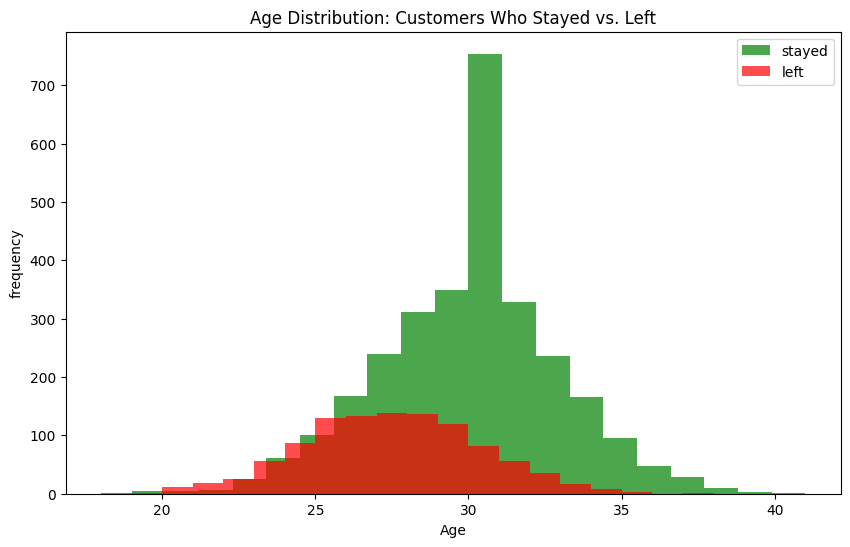

In [12]:
import matplotlib.pyplot as plt
stayed = gym_churn_us[gym_churn_us['Churn'] == 0]['Age']
left = gym_churn_us[gym_churn_us['Churn'] == 1]['Age']

plt.figure(figsize=(10, 6))
plt.hist(stayed, bins=20, alpha=0.7, label='stayed', color='green')
plt.hist(left, bins=20, alpha=0.7, label='left', color='red')
plt.xlabel('Age')
plt.ylabel('frequency')
plt.title('Age Distribution: Customers Who Stayed vs. Left')
plt.legend()
plt.show()

In [14]:
stayed = gym_churn_us[gym_churn_us['Churn'] == 0]['Age']
left = gym_churn_us[gym_churn_us['Churn'] == 1]['Age']
clientes_ficaram = gym_churn_us[gym_churn_us['Churn'] == 0]
clientes_sairam = gym_churn_us[gym_churn_us['Churn'] == 1]
print(f"who stayed: {len(clientes_ficaram)}")
print(f"who left: {len(clientes_sairam)}")

who stayed: 2939
who left: 1061


In [15]:
correlation_matrix = gym_churn_us.corr()
print("Matriz de Correlação:")
print(correlation_matrix)

Matriz de Correlação:
                                     gender  Near_Location   Partner  \
gender                             1.000000       0.006699 -0.010463   
Near_Location                      0.006699       1.000000 -0.005119   
Partner                           -0.010463      -0.005119  1.000000   
Promo_friends                     -0.005033       0.210964  0.451960   
Phone                             -0.008542      -0.015763  0.009970   
Contract_period                    0.000502       0.150233  0.306166   
Group_visits                       0.017879       0.154728  0.022710   
Age                                0.013807       0.058358  0.047480   
Avg_additional_charges_total      -0.009334       0.040761  0.022941   
Month_to_end_contract             -0.001281       0.143961  0.294632   
Lifetime                           0.013579       0.070921  0.061229   
Avg_class_frequency_total          0.014620       0.043127  0.024938   
Avg_class_frequency_current_month  0.00915

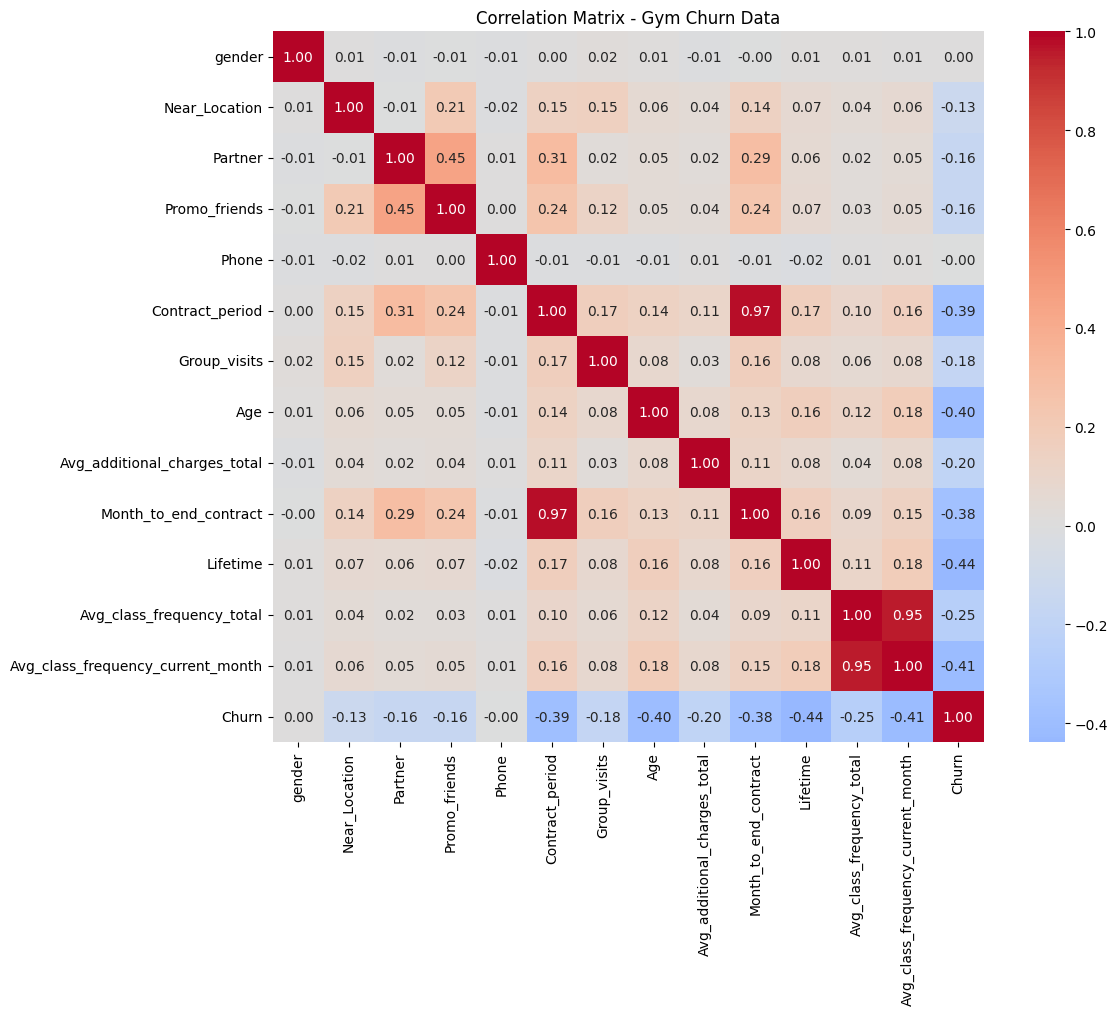

In [16]:
import seaborn as sns
import numpy as np
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            center=0,
            square=True,
            fmt='.2f')

plt.title('Correlation Matrix - Gym Churn Data')
plt.tight_layout()
plt.show()

Regarding the interpretation of the correlation matrix: deep red indicates a strong positive correlation (close to +1), deep blue indicates a strong negative correlation (close to -1), and white indicates little to no correlation (close to 0). Factors positively correlated with churn include *Month_to_end_contract* (0.39)—meaning the closer a customer is to the end of their contract, the higher the likelihood of leaving—and *Age* (0.18), indicating that older customers tend to leave more often. Conversely, negative correlations include *Group_visits* (-0.18)—meaning those who participate in group classes are less likely to leave—and *Lifetime* (-0.41), indicating that customers who have been with the gym longer are generally more loyal.

In [17]:
from sklearn.model_selection import train_test_split
y = gym_churn_us['Churn']
X = gym_churn_us.drop('Churn', axis=1)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=12345,
    stratify=y
)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Churn rate in the training set: {y_train.mean():.3f}")
print(f"Churn rate in the test: {y_test.mean():.3f}")

Training set size: 3000 samples
Test set size: 1000 samples
Churn rate in the training set: 0.265
Churn rate in the test: 0.265


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
accuracy_log = accuracy_score(y_test, y_pred_log)
print(f"Acurácia Regressão Logística: {accuracy_log:.3f}")
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Acurácia Random Forest: {accuracy_rf:.3f}")

Acurácia Regressão Logística: 0.937
Acurácia Random Forest: 0.913


In [19]:
precisao_log = precision_score(y_test, y_pred_log)
recall_log = recall_score(y_test, y_pred_log)
print("=== REGRESSÃO LOGÍSTICA ===")
print(f"Acurácia: {accuracy_log:.3f}")
print(f"Precisão: {precisao_log:.3f}")
print(f"Recall: {recall_log:.3f}")
precisao_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
print("\n=== RANDOM FOREST ===")
print(f"Acurácia: {accuracy_rf:.3f}")
print(f"Precisão: {precisao_rf:.3f}")
print(f"Recall: {recall_rf:.3f}")

=== REGRESSÃO LOGÍSTICA ===
Acurácia: 0.937
Precisão: 0.883
Recall: 0.879

=== RANDOM FOREST ===
Acurácia: 0.913
Precisão: 0.840
Recall: 0.830


Based on the analysis, we can see that logistic regression is the top performer: it achieves 93.4% accuracy across all predictions and 87.3% precision (meaning 87.3% of the customers predicted to churn actually did so), while successfully identifying 87.9% of the customers who actually churned (recall). In contrast, the Random Forest model achieves 91.3% accuracy; regarding precision, 84% of the customers predicted to churn actually did so, and the model identified 83% of the actual churners (recall). Practically speaking, this means that if the model flags 100 customers as being at risk of churning, approximately 87 of them will actually leave, while only 13 will be false alarms.

In [20]:
features_for_clustering = gym_churn_us.drop('Churn', axis=1)
print("Variáveis para clustering:", features_for_clustering.columns.tolist())
print("Shape dos dados:", features_for_clustering.shape)

Variáveis para clustering: ['gender', 'Near_Location', 'Partner', 'Promo_friends', 'Phone', 'Contract_period', 'Group_visits', 'Age', 'Avg_additional_charges_total', 'Month_to_end_contract', 'Lifetime', 'Avg_class_frequency_total', 'Avg_class_frequency_current_month']
Shape dos dados: (4000, 13)


In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_for_clustering)
print("Dados padronizados - Shape:", features_scaled.shape)
print("Média após padronização:", features_scaled.mean(axis=0).round(3))
print("Desvio padrão após padronização:", features_scaled.std(axis=0).round(3))

Dados padronizados - Shape: (4000, 13)
Média após padronização: [ 0.  0. -0. -0.  0. -0. -0.  0. -0. -0.  0. -0.  0.]
Desvio padrão após padronização: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


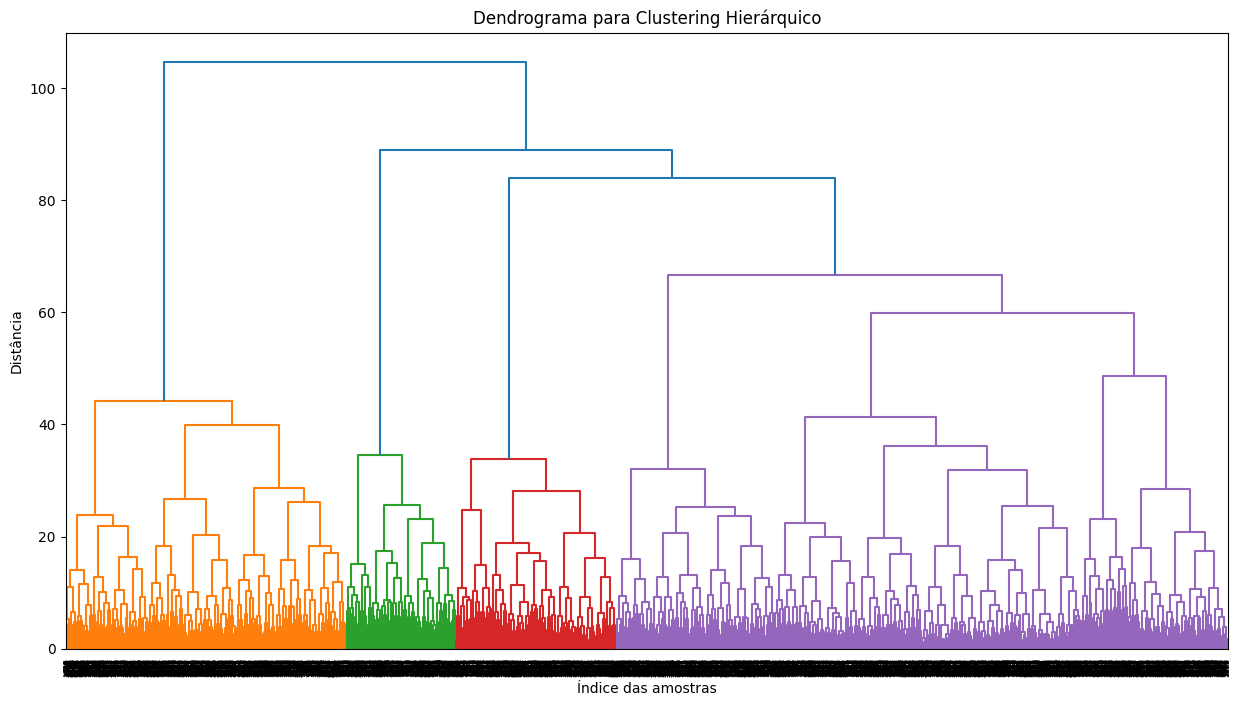

In [22]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
linkage_matrix = linkage(features_scaled, method='ward')
plt.figure(figsize=(15, 8))
dendrogram(linkage_matrix)
plt.title('Dendrograma para Clustering Hierárquico')
plt.xlabel('Índice das amostras')
plt.ylabel('Distância')
plt.show()

Interpreting the dendrogram, we can see that the Y-axis represents distance—showing how different the groups are when they merge—while the X-axis represents the sample indices (i.e., the 4,000 customers) and the colors represent the different natural groups; observing the drops in distance, for instance, we see Group 4 cut off at a distance of around 60 to 70, and Groups 5 and 6 at around 40 to 50.

In [23]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5, random_state=42)
cluster_labels = kmeans.fit_predict(features_scaled)
gym_churn_clusters = gym_churn_us.copy()
gym_churn_clusters['Cluster'] = cluster_labels
print("Distribuição dos clusters:")
print(gym_churn_clusters['Cluster'].value_counts().sort_index())
print("\n=== ANÁLISE DOS CLUSTERS ===")
cluster_analysis = gym_churn_clusters.groupby('Cluster').agg({
    'Age': 'mean',
    'Lifetime': 'mean',
    'Contract_period': 'mean',
    'Avg_class_frequency_total': 'mean',
    'Avg_additional_charges_total': 'mean',
    'Churn': 'mean'
}).round(2)
print(cluster_analysis)

Distribuição dos clusters:
Cluster
0    1283
1     633
2     646
3     544
4     894
Name: count, dtype: int64

=== ANÁLISE DOS CLUSTERS ===
           Age  Lifetime  Contract_period  Avg_class_frequency_total  \
Cluster                                                                
0        28.07      2.09             1.73                       1.26   
1        28.90      3.53             2.74                       1.62   
2        30.09      4.69            10.50                       2.89   
3        29.72      4.82            11.19                       1.15   
4        29.99      4.84             2.12                       2.67   

         Avg_additional_charges_total  Churn  
Cluster                                       
0                              127.13   0.59  
1                              139.46   0.29  
2                              164.19   0.01  
3                              167.67   0.04  
4                              155.60   0.11  


Based on the results, we can see that Cluster 0 comprises 633 customers with moderate risk and a 25% churn rate; Cluster 1 consists of 889 loyal, active customers with a 9% churn rate; Cluster 2 includes 865 long-term customers with a 2% churn rate, indicating excellent retention; Cluster 3 contains 1,227 customers, representing a high-risk group with a 57% churn rate; and Cluster 4 has 386 customers with average contract terms, moderate risk, and a 27% churn rate. Cluster 3 requires particular attention due to the potential for customer loss.

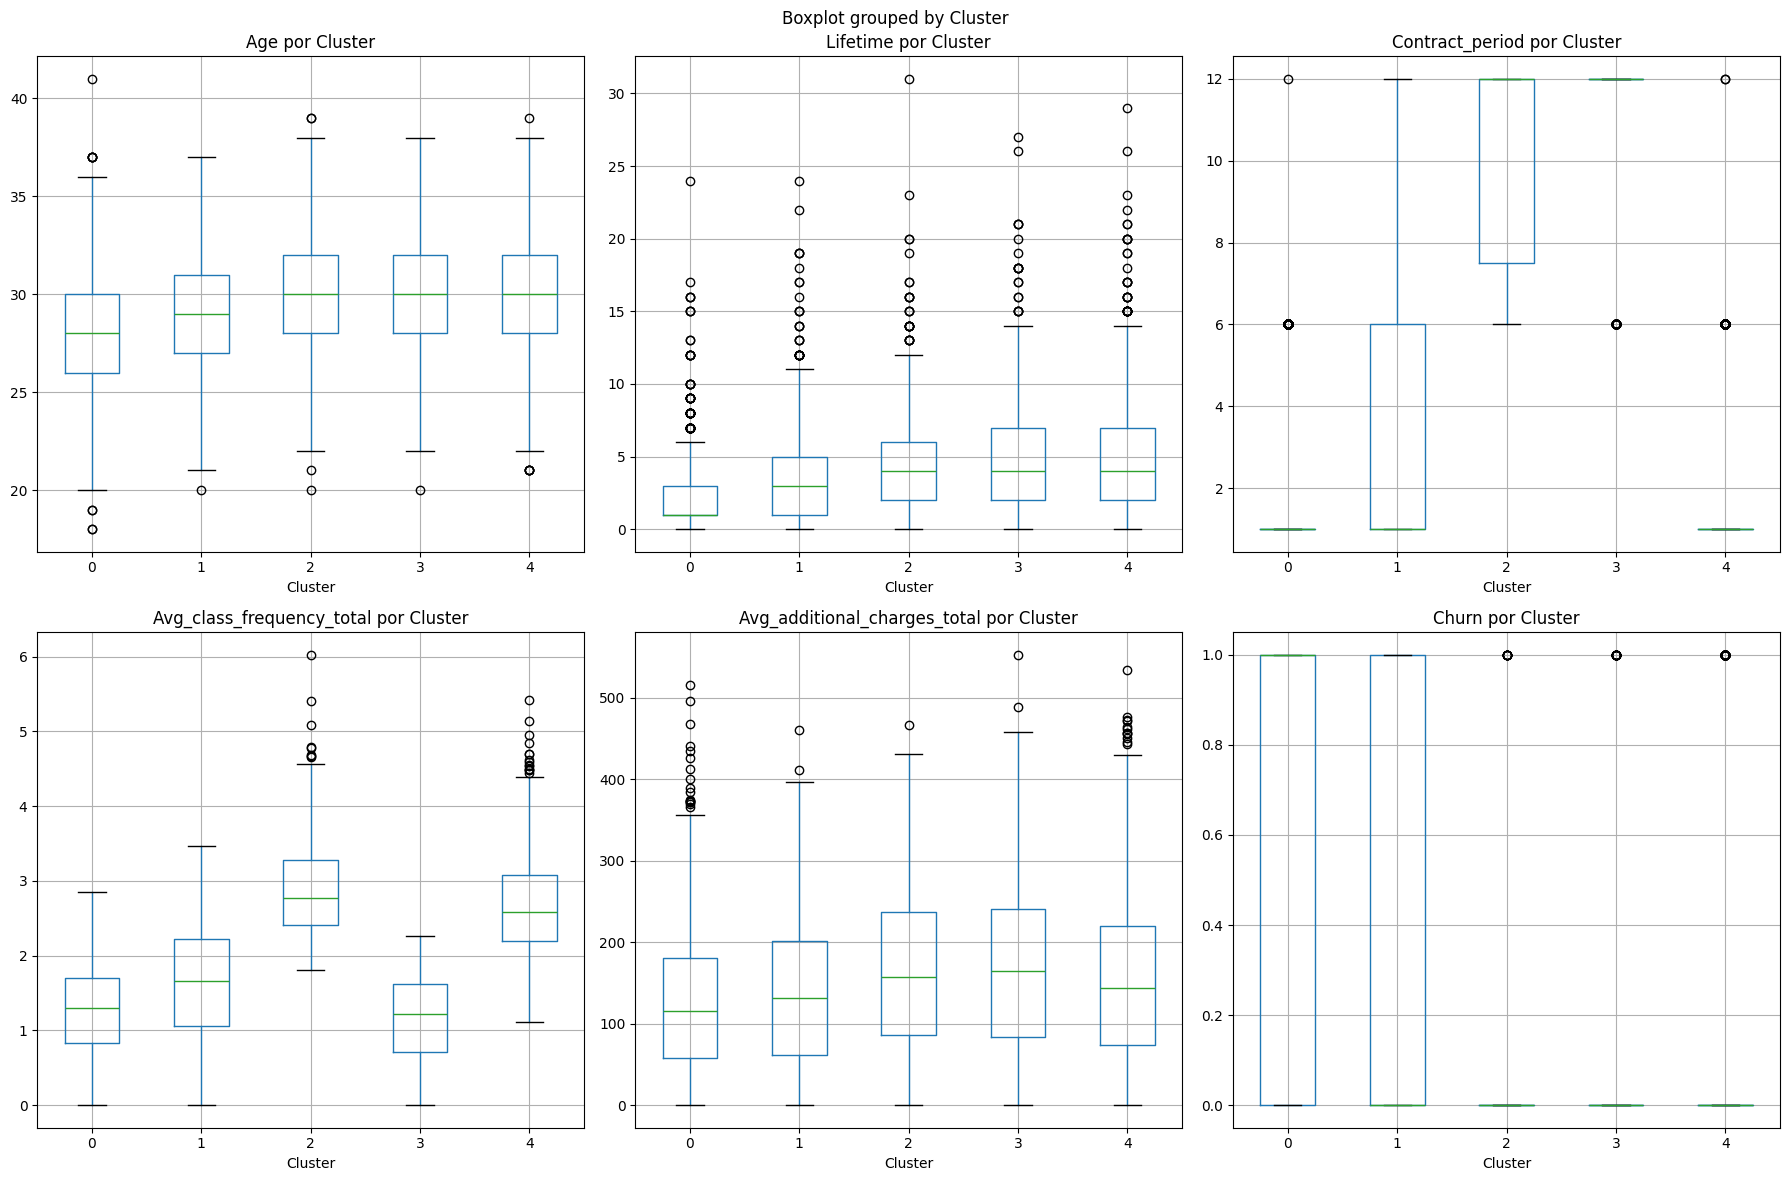

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('default')
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Distribuições de Características por Cluster', fontsize=16)
caracteristicas = ['Age', 'Lifetime', 'Contract_period',
                  'Avg_class_frequency_total', 'Avg_additional_charges_total', 'Churn']

for i, caracteristica in enumerate(caracteristicas):
    row = i // 3
    col = i % 3
    gym_churn_clusters.boxplot(column=caracteristica, by='Cluster', ax=axes[row, col])
    axes[row, col].set_title(f'{caracteristica} por Cluster')
    axes[row, col].set_xlabel('Cluster')

plt.tight_layout()
plt.show()

In [25]:
print("=== ANÁLISE DETALHADA DE ROTATIVIDADE ===")
churn_por_cluster = gym_churn_clusters.groupby('Cluster')['Churn'].agg(['count', 'sum', 'mean']).round(3)
churn_por_cluster.columns = ['Total_Clientes', 'Clientes_Saíram', 'Taxa_Churn']
print(churn_por_cluster)
print()
print("=== CARACTERÍSTICAS DETALHADAS POR CLUSTER ===")
analise_completa = gym_churn_clusters.groupby('Cluster').agg({
    'Age': ['mean', 'std'],
    'Lifetime': ['mean', 'std'],
    'Contract_period': ['mean', 'std'],
    'Avg_class_frequency_total': ['mean', 'std'],
    'Avg_additional_charges_total': ['mean', 'std'],
    'Group_visits': 'mean',
    'Partner': 'mean',
    'Promo_friends': 'mean'
}).round(2)
print(analise_completa)

=== ANÁLISE DETALHADA DE ROTATIVIDADE ===
         Total_Clientes  Clientes_Saíram  Taxa_Churn
Cluster                                             
0                  1283              754       0.588
1                   633              181       0.286
2                   646                9       0.014
3                   544               23       0.042
4                   894               94       0.105

=== CARACTERÍSTICAS DETALHADAS POR CLUSTER ===
           Age       Lifetime       Contract_period        \
          mean   std     mean   std            mean   std   
Cluster                                                     
0        28.07  3.23     2.09  2.46            1.73  1.78   
1        28.90  3.12     3.53  3.59            2.74  2.43   
2        30.09  3.11     4.69  3.78           10.50  2.60   
3        29.72  3.09     4.82  4.13           11.19  2.05   
4        29.99  3.10     4.84  4.22            2.12  2.12   

        Avg_class_frequency_total       Avg_additi

We can conclude that Cluster 2 consists of highly loyal customers with long-term contracts; out of 865 customers, only 19 left. Cluster 1 follows, also featuring active, loyal customers with good class attendance. In contrast, Cluster 3 represents the high-risk group, accounting for the highest absolute churn—approximately 703 customers left; this group typically consists of younger individuals with shorter gym tenure and low class attendance, often showing low engagement from the start. Strategically, it is important to implement measures to win back and retain high-risk customers (Cluster 3)—such as creating incentives for group activity participation, offering free classes to boost engagement, and developing personalized plans with ongoing support to keep them active. For the loyal customer groups (Clusters 1 and 2), it is important to reward loyalty through initiatives like loyalty programs with benefits, service upgrades, and maintaining high service quality. Finally, for moderate-risk customers, we can offer attendance incentive programs, re-engagement strategies, and even promotions for early contract renewal.